# shearing_sheet — Saturn's rings shearing box (pure Rust)

Straight port of REBOUND's `examples/shearing_sheet` (SEI integrator, octree self-gravity, tree collision search, hard-sphere collisions with the Bridges restitution law, shear-periodic boundary). Runs a short simulation and plots the particle positions.

Crate: `C:\Users\nsh\Developer\github\rustSolveIt_Win11_SUNDIALS_7_8_0\rebound_rust`. This notebook builds the example with cargo (MSVC toolchain, zero unsafe / zero dependencies / zero warnings), runs it, and displays its output. See `rebound_rust.md` for the full provenance.

In [1]:
import os, subprocess
CRATE = r"C:\Users\nsh\Developer\github\rustSolveIt_Win11_SUNDIALS_7_8_0\rebound_rust"
print(subprocess.run(["cargo", "build", "--release", "--example", "shearing_sheet"],
      cwd=CRATE, capture_output=True, text=True).stderr)

   Compiling rebound_rs v5.1.1 (C:\Users\nsh\Developer\github\rustSolveIt_Win11_SUNDIALS_7_8_0\rebound_rust)
    Finished `release` profile [optimized] target(s) in 0.26s



In [2]:
exe = os.path.join(CRATE, "target", "release", "examples", "shearing_sheet_test.exe")
res = subprocess.run([exe, "400"], cwd=os.path.join(CRATE, "porttest"),
                     capture_output=True, text=True)
print(res.stdout)
print(res.stderr)

Toomre wavelength: 61.009899
N after init: 1482
final: t=1.91217633050229269e+04 steps=400 collisions=102533




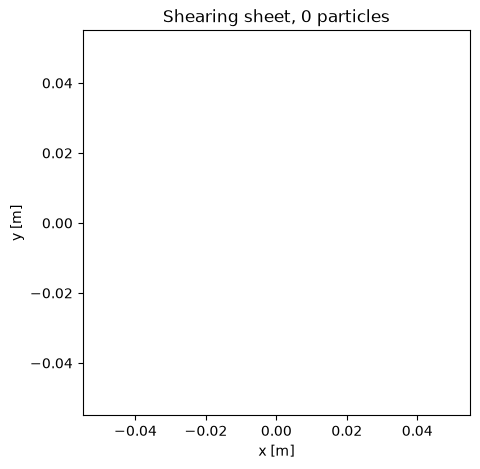

In [3]:
# Plot the final particle positions from the bit dump written by the run
import matplotlib.pyplot as plt
xs, ys = [], []
with open(os.path.join(CRATE, "porttest", "state_rust_final.txt")) as f:
    for line in f:
        parts = line.split()
        if len(parts) == 7 and parts[0].isdigit():
            import struct
            x = struct.unpack("<d", int(parts[1], 16).to_bytes(8, "little"))[0]
            y = struct.unpack("<d", int(parts[2], 16).to_bytes(8, "little"))[0]
            xs.append(x); ys.append(y)
plt.figure(figsize=(5, 5))
plt.scatter(xs, ys, s=2)
plt.xlabel("x [m]"); plt.ylabel("y [m]"); plt.title(f"Shearing sheet, {len(xs)} particles")
plt.show()